<a href="https://colab.research.google.com/github/slin789/geog761lab/blob/main/geog761_Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction
Welcome to Lab 2, in this lab we will take our first steps into applying ML to satellite data, using landcover analysis as our primary goal.

As covered in Lecture 2, landcover classification is the quintessential remote sensing task in the civil sector. The LandSat programme (Lecture 3) was originally developed in large part to enable the USA to monitor landcover more easily for a range of agricultral, govermental and finacial problemsets. It remains a primary task for governments and companies around the world.

This is a pixel-wise ML task. We will apply two methods, both of which are available in GEE as ready-to-go algorithms. In this instance we are happy to go with built-in as it allows us to become familiar with an end-to-end GEE ML workflow without getting bogged down in technical detail. No need to re-invent the wheel unless you are going to the [moon](https://www.nasa.gov/feature/ames/artemis-moon-rover-s-wheels-are-ready-to-roll/).

Remember that this is a set of exercises and tutorials that escalate in difficulty. Always show your working and do not neccesarily expect to get full marks on everything.

Use the resources available to you outside of this material. I expect you to search for concepts or terms you do not understand and to look at the documentation of the code packages that we are using in the first instance of getting stuck. But do then of course ask us for help in the lab and on EdDiscussion.
_______________________________________________________________________________

# Set up

In [46]:
# Install libs if needed, note the --quiet option means a lot less annoying info than as Lab 1 when we did the same!
!pip install geemap --quiet

In [47]:
# Set up GEE API
import ee
ee.Authenticate()
ee.Initialize(project='geog761-irene') #<- Remember to change this to your own project's name!

In [48]:
# Import other libs
import geemap
import geopandas as gpd
import pandas as pd

# Define Area of Interest (AOI)

In [49]:
# Define area of interest (e.g., Wellington, NZ)
aoi = ee.Geometry.Rectangle([174.6, -41.4, 174.9, -41.2])
Map = geemap.Map(center=[-41.3, 174.75], zoom=10)
Map.addLayer(aoi, {}, 'AOI')

# Visualize on the map to check got it right... (always a good idea)
Map

Map(center=[-41.3, 174.75], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

# Load and Cloud Mask Imagery from Earth Engine

In [50]:
# Set up your filter Sentinel-2 imagery
# A function that masks clouds in your S2 images via QA band
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloudBitMask = 1 << 10
    cirrusBitMask = 1 << 11
    mask = qa.bitwiseAnd(cloudBitMask).eq(0).And(
           qa.bitwiseAnd(cirrusBitMask).eq(0))
    return image.updateMask(mask).divide(10000).select(['B2', 'B3', 'B4', 'B8'])

# Now build the clean collection with selected bands
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(aoi)
      .filterDate('2021-01-01', '2021-12-31')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
      .map(mask_s2_clouds)
      .median() #<- think about this step and what it is doing to your image when you build your single composite from the image collection
      .clip(aoi))

# (1) What other mathematical [compositing](https://developers.google.com/earth-engine/guides/ic_composite_mosaic) approaches could you take when building your single image from the filtered image collection you create in the cell above? Hint: you currently are doing a 'median-composite'. (3 pts)

Other mathematical compositing approaches include mean, minimum, and maximum composites. A mean composite calculates the average pixel value across the image collection, while minimum and maximum composites select the lowest or highest pixel value at each location. Different methods may emphasise different land-cover characteristics and can be affected differently by clouds, shadows, or other outliers.

In [51]:
# Set up the visualisation and then once again check it has worked, stacking layers in a sensible order
Map = geemap.Map(center=[-41.3, 174.75], zoom=11) #<- reset the map object to clear out other layers from earlier cells
Map.addLayer(s2, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}, 'S2 RGB')
Map.addLayer(aoi, {'color': 'red'}, 'AOI')
Map

Map(center=[-41.3, 174.75], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

________________________________________________________________________________

# Training data

We are going to train our data using the European Space Agency (ESA) world landcover map. Given that this is derived from satellite data our logic is at risk of becoming a little circular here. But as a training exercise it is a good way to have easy to access training data of the right size and type to apply to our image.

There are a wide range of landcover datasets in the GEE catalogue that you can use for this purpose:
*   https://developers.google.com/earth-engine/datasets/tags/landuse-landcover

First, we will load in the landcover map we will use to create our training dataset (https://developers.google.com/earth-engine/datasets/catalog/ESA_WorldCover_v100):



Next we need to use our landcover map to [sample](https://developers.google.com/earth-engine/apidocs/ee-image-sample) the Sentinel 2 image, associating each pixel of a given landcover with the spectral band values 'beneath' it.

In [52]:
# Define valid WorldCover classes (10 to 100, spaced by 10)
valid_classes = ee.List.sequence(10, 100, 10)

# Need to change this to sequential list to avoid the algs thiniing there are 99 classes rather than 9
remap_to = ee.List.sequence(1, 10)

# Load landcover map
landcover = ee.Image('ESA/WorldCover/v100/2020').select('Map').clip(aoi)

# Remap labels: create a new band with remapped values (10 → 1, ..., 100 → 10)
landcover_remapped = landcover.remap(valid_classes, remap_to).rename('Map_remapped')

In [53]:
print(valid_classes.getInfo())
print(remap_to.getInfo())

[10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


# (2) What year of data was this landcover map (accessed in the cell above) created on? (1 pt)

2020 year

In [54]:
# Add landcover original and remapped as bands to Sentinel-2 image
training_data = s2.addBands(landcover_remapped).addBands(landcover_remapped)

Let's inspect the resulting training dataset and make sure that you understand what you have built here.

We are going to:
- Print the first few rows (client-side).
- Check the number of samples per class (server-side with reduceColumns).

This may take a little time to run as we request data both client and server side.

In [55]:
# Sample the image
bands = ['B2', 'B3', 'B4', 'B8']
sample = training_data.select(bands + ['Map_remapped']).sample(
    region=aoi,
    scale=10,
    numPixels=5000,
    seed=2,
    geometries=True)

# Print first 10 sample points (client-side)
first_10 = sample.limit(10).getInfo()

print('\nFirst 10 training samples:')
for i, feature in enumerate(first_10['features']):
    props = feature['properties']
    print(f"Sample {i+1}: Class={props['Map_remapped']}, B2={props['B2']}, B3={props['B3']}, B4={props['B4']}, B8={props['B8']}")

# Count number of samples per class (server-side)
class_counts = sample.reduceColumns(
    reducer=ee.Reducer.frequencyHistogram(),
    selectors=['Map_remapped'])

print('\nClass distribution in sample:')
print(class_counts.getInfo())



First 10 training samples:
Sample 1: Class=8, B2=0.026799999177455902, B3=0.026499999687075615, B4=0.005799999926239252, B8=0.002899999963119626
Sample 2: Class=8, B2=0.039400000125169754, B3=0.028750000521540642, B4=0.0077333333902060986, B8=0.004800000227987766
Sample 3: Class=1, B2=0.01510000042617321, B3=0.03849999979138374, B4=0.02287999913096428, B8=0.23090000450611115
Sample 4: Class=8, B2=0.04749999940395355, B3=0.03200000151991844, B4=0.007666666526347399, B8=0.004550000187009573
Sample 5: Class=1, B2=0.011644444428384304, B3=0.02458333410322666, B4=0.018553845584392548, B8=0.2840000092983246
Sample 6: Class=5, B2=0.10279999673366547, B3=0.09380000084638596, B4=0.09399999678134918, B8=0.12139999866485596
Sample 7: Class=1, B2=0.025599999353289604, B3=0.049800001084804535, B4=0.03869999945163727, B8=0.3140000104904175
Sample 8: Class=8, B2=0.04417499899864197, B3=0.032229166477918625, B4=0.008299999870359898, B8=0.003800000064074993
Sample 9: Class=8, B2=0.03579999879002571, B

# (3) What type of landcover is being sampled in sample number 2 of the dataset? Make sure your random seed is set to 2 in the sampling code so that you get the same answer as me. (1 pt)

Permanent water bodies

We are now ready to start machine learning on classifying the landcover of Wellington!
________________________________________________________________________________

# Random Forest Classification for Landcover
Let us do machine learning properly and first apply a 70/20/10 split that allows us to produce some accuracy statistics.

In [56]:
# Add random column
sample = sample.randomColumn('random')

# Split
train = sample.filter(ee.Filter.lt('random', 0.7))
valid = sample.filter(ee.Filter.And(ee.Filter.gte('random', 0.7), ee.Filter.lt('random', 0.9)))
test = sample.filter(ee.Filter.gte('random', 0.9))

Our next task is to set up a classifier object, followed by applying it to the image using the .classify operator. This operator hides a LOT of behind the scenes plumbing from Google.

We use the [GEE Random Forest](https://developers.google.com/earth-engine/apidocs/ee-classifier-smilerandomforest) model that they have pre-built for us. Specifying the number of trees to use is the only variable we must set. Othe variables are available, read the docs!

In [57]:
# Train the RF model
classifier = ee.Classifier.smileRandomForest(numberOfTrees=100).train(
    features=train,
    classProperty='Map_remapped',
    inputProperties=bands)

With the model trained, we just apply it simply using the '.classify' operator.

In [58]:
# Classify image
classified = s2.select(bands).classify(classifier)

Let's visualize what we have just made!

In [59]:
# Classified image viz, fresh set up again to make sure we have exactly what we want displayed.
Map = geemap.Map()
Map.centerObject(aoi, 10)
Map.addLayer(classified.randomVisualizer(), {}, 'Classified')
Map.addLayer(landcover_remapped.randomVisualizer(), {} ,'ESA Landcover')
Map

Map(center=[-41.30004624634492, 174.74999999999935], controls=(WidgetControl(options=['position', 'transparent…

In [60]:
s2_collection = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(aoi)
    .filterDate('2022-01-01', '2022-12-31')
)

s2 = s2_collection.median()

In [61]:
print(
    'S2 start:',
    ee.Date(s2_collection.aggregate_min('system:time_start'))
      .format('YYYY-MM-dd').getInfo()
)

print(
    'S2 end:',
    ee.Date(s2_collection.aggregate_max('system:time_start'))
      .format('YYYY-MM-dd').getInfo()
)

S2 start: 2022-01-03
S2 end: 2022-12-29


In [62]:
print(
    'ESA index:',
    landcover_remapped.get('system:index').getInfo()
)

print(
    'ESA time:',
    landcover_remapped.get('system:time_start').getInfo()
)

ESA index: 2020
ESA time: 1577836800000


In [63]:
palette = [
    '006400', 'ffbb22', 'ffff4c', 'f096ff',
    'fa0000', 'b4b4b4', 'f0f0f0', '0064c8',
    '0096a0', '00cf75', 'fae6a0'
]

vis = {
    'min': 0,
    'max': 10,
    'palette': palette
}

Map.addLayer(classified, vis, 'Classified')
Map.addLayer(landcover_remapped, vis, 'ESA Landcover')
Map

Map(center=[-41.30004624634492, 174.74999999999935], controls=(WidgetControl(options=['position', 'transparent…

# (4) Look at the ESA landcover map and our resulting random forest classified Sentinel 2 image map. How are they different and what might be some causes of this difference? (5 pts)

1.The obvious difference between the ESA landcover map and resulting Random Forest classified Sentinel-2 image map is the color. The classified one has green color and its ocean is blue. The ESA one has more purple, and the ocean color is not blue; it's another green. To compare them better, I would change them to the same color. The classified picture is more fragmented. I guess the classified image has more detail in different areas. The ESA map has clearer edges between different areas than the classified one.

2.This may be because some land-cover classes have similar spectral characteristics, so the Random Forest may misclassify some pixels. Differences in training samples may also affect the classification result.

Finally, we will apply our test data split and produce the [summary statistics](https://developers.google.com/machine-learning/crash-course/classification/accuracy-precision-recall) that we need to make smart choices about our training approach.

In [64]:
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd


# Validate
validated = valid.classify(classifier, 'predicted')

# Function to export data for confusion matrix
def fc_to_lists(fc, classProp, predProp):
    values = fc.aggregate_array(classProp).getInfo()
    preds = fc.aggregate_array(predProp).getInfo()
    return values, preds

# Get predicted vs actual from validation set
y_true, y_pred = fc_to_lists(validated, 'Map_remapped', 'predicted')

# Labels for original classes
label_map = {i + 1: valid_classes.get(i).getInfo() for i in range(10)}
label_names = [label_map[i + 1] for i in range(10)]

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(range(1, 11)))
report = classification_report(y_true, y_pred, labels=list(range(1, 11)), target_names=[str(l) for l in label_names])

# Pretty-print
print("Confusion Matrix:")
print(pd.DataFrame(cm, index=[f"Actual {l}" for l in label_names],
                       columns=[f"Pred {l}" for l in label_names]))
print("\nClassification Report:")
print(report)

Confusion Matrix:
            Pred 10  Pred 20  Pred 30  Pred 40  Pred 50  Pred 60  Pred 70  \
Actual 10       230        1       31        0        2        0        0   
Actual 20         1        0        0        0        0        0        0   
Actual 30        39        0      154        0        4        0        0   
Actual 40         0        0        0        0        0        0        0   
Actual 50         5        0        3        0       23        2        0   
Actual 60         0        0        1        0        2        1        0   
Actual 70         0        0        0        0        0        0        0   
Actual 80         0        0        0        0        6        0        0   
Actual 90         0        0        3        0        0        0        0   
Actual 100        0        0        0        0        0        0        0   

            Pred 80  Pred 90  Pred 100  
Actual 10         0        0         0  
Actual 20         0        0         0  
Actual 30  

# (5) Exercise: modify the code so that you feed into your random forest classifier that has been trained on 2020 data, on other years of Sentinel 2 data than 2020. Produce a publication quality figure that presents the following:
*   Landcover maps of Wellington for 2018, 2022 and 2024
*   The Test accuracy averages of the RF classifier for 2020.
*   Include a sentence in your figure caption that explains why you cannot state the accuracy of the classifier for years other than 2020.

(15 pts)
_______________________________________________________________________________


In [65]:
from sklearn.metrics import accuracy_score


# Calculate the overall accuracy of the held-out 2020 test data.
test_accuracy_2020 = accuracy_score(
    y_true,
    y_pred
)

# Create a dictionary containing the classification statistics.
# This is used to obtain the macro-average F1 score for the figure.
report_dict = classification_report(
    y_true,
    y_pred,
    labels=list(range(1, 11)),
    target_names=[
        str(label)
        for label in label_names
    ],
    output_dict=True,
    zero_division=0
)

print(
    f'2020 test accuracy: '
    f'{test_accuracy_2020:.2%}'
)

print(
    f'2020 macro-average F1: '
    f'{report_dict["macro avg"]["f1-score"]:.2%}'
)

2020 test accuracy: 90.32%
2020 macro-average F1: 35.26%


In [66]:
import ee
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


# ============================================================
# 1. Calculate the 2020 validation statistics
# ============================================================

# Apply the trained classifier to the held-out validation samples.
validated = valid.classify(classifier, 'predicted')


def fc_to_lists(fc, actual_property, predicted_property):
    """Download actual and predicted labels from Earth Engine."""

    actual = fc.aggregate_array(actual_property).getInfo()
    predicted = fc.aggregate_array(predicted_property).getInfo()

    return actual, predicted


# Download the actual and predicted labels.
y_true, y_pred = fc_to_lists(
    validated,
    'Map_remapped',
    'predicted'
)

y_true = np.asarray(y_true, dtype=int)
y_pred = np.asarray(y_pred, dtype=int)

# Obtain the land-cover class names.
label_names = [
    str(name)
    for name in valid_classes.getInfo()
]

# Assume that the remapped class IDs begin at 1.
class_ids = list(
    range(1, len(label_names) + 1)
)

# Calculate the overall 2020 test accuracy.
test_accuracy_2020 = accuracy_score(
    y_true,
    y_pred
)

# Calculate all classification statistics.
report_dict = classification_report(
    y_true,
    y_pred,
    labels=class_ids,
    target_names=label_names,
    output_dict=True,
    zero_division=0
)

# Calculate the confusion matrix.
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=class_ids
)

cm_df = pd.DataFrame(
    cm,
    index=[
        f'Actual {name}'
        for name in label_names
    ],
    columns=[
        f'Predicted {name}'
        for name in label_names
    ]
)

print('2020 confusion matrix:')
display(cm_df)

print(
    f'2020 test accuracy: '
    f'{test_accuracy_2020:.2%}'
)

print(
    f'2020 macro-average F1: '
    f'{report_dict["macro avg"]["f1-score"]:.2%}'
)


# ============================================================
# 2. Recover the exact predictor names used by the RF
# ============================================================

classifier_information = classifier.explain().getInfo()

predictor_bands = list(
    classifier_information['importance'].keys()
)

print('\nPredictor bands used by the classifier:')
print(predictor_bands)


# ============================================================
# 3. Define the Wellington study area
# ============================================================

# Earth Engine Rectangle uses [west, south, east, north].
# Replace this with the original 2020 study area if available.
wellington = ee.Geometry.Rectangle([
    174.55,
    -41.55,
    175.05,
    -41.05
])


# ============================================================
# 4. Define the Sentinel-2 preprocessing functions
# ============================================================

def mask_s2_clouds(image):
    """Mask invalid, cloud, cirrus, shadow and snow pixels."""

    scl = image.select('SCL')

    clear_mask = (
        scl.neq(0)          # No data
        .And(scl.neq(1))    # Saturated or defective
        .And(scl.neq(3))    # Cloud shadow
        .And(scl.neq(8))    # Medium-probability cloud
        .And(scl.neq(9))    # High-probability cloud
        .And(scl.neq(10))   # Cirrus
        .And(scl.neq(11))   # Snow or ice
    )

    return image.updateMask(clear_mask)


def add_indices(image):
    """Add NDVI and NDBI predictor bands."""

    ndvi = image.normalizedDifference(
        ['B8', 'B4']
    ).rename('NDVI')

    ndbi = image.normalizedDifference(
        ['B11', 'B8']
    ).rename('NDBI')

    return image.addBands([
        ndvi,
        ndbi
    ])


def prepare_s2_image(image):
    """Preprocess an image and retain only RF predictor bands."""

    image = mask_s2_clouds(image)
    image = add_indices(image)

    # Selecting bands before calculating the annual median
    # substantially reduces Earth Engine memory usage.
    return image.select(predictor_bands)


# ============================================================
# 5. Create a lightweight annual composite
# ============================================================

def make_year_composite(year):
    """Create a memory-efficient annual Sentinel-2 composite."""

    start_date = ee.Date.fromYMD(
        year,
        1,
        1
    )

    end_date = ee.Date.fromYMD(
        year + 1,
        1,
        1
    )

    collection = (
        ee.ImageCollection(
            'COPERNICUS/S2_SR_HARMONIZED'
        )
        .filterBounds(wellington)
        .filterDate(
            start_date,
            end_date
        )
        .filter(
            ee.Filter.lt(
                'CLOUDY_PIXEL_PERCENTAGE',
                40
            )
        )

        # Use only the least-cloudy scenes to avoid memory errors.
        .sort('CLOUDY_PIXEL_PERCENTAGE')
        .limit(12)
        .map(prepare_s2_image)
    )

    # The 100 m projection is used for figure production.
    # It avoids processing millions of unnecessary 10 m pixels.
    composite = (
        collection
        .median()
        .clip(wellington)
        .reproject(
            crs='EPSG:2193',
            scale=100
        )
    )

    return composite


# ============================================================
# 6. Apply the 2020 classifier to the required years
# ============================================================

years = [
    2018,
    2022,
    2024
]

# Create the annual Sentinel-2 composites.
annual_composites = {
    year: make_year_composite(year)
    for year in years
}

# Apply the same RF classifier to every annual composite.
landcover_maps = {
    year: (
        annual_composites[year]
        .classify(classifier)
        .rename('landcover')
        .toInt()
    )
    for year in years
}

print(
    '\nThe 2018, 2022 and 2024 classification '
    'images were created successfully.'
)

2020 confusion matrix:


,Predicted 10,Predicted 20,Predicted 30,Predicted 40,Predicted 50,Predicted 60,Predicted 70,Predicted 80,Predicted 90,Predicted 100
Actual 10,230,1,31,0,2,0,0,0,0,0
Actual 20,1,0,0,0,0,0,0,0,0,0
Actual 30,39,0,154,0,4,0,0,0,0,0
Actual 40,0,0,0,0,0,0,0,0,0,0
Actual 50,5,0,3,0,23,2,0,2,0,0
Actual 60,0,0,1,0,2,1,0,1,0,0
Actual 70,0,0,0,0,0,0,0,0,0,0
Actual 80,0,0,0,0,6,0,0,553,0,0
Actual 90,0,0,3,0,0,0,0,0,0,0
Actual 100,0,0,0,0,0,0,0,0,0,0


2020 test accuracy: 90.32%
2020 macro-average F1: 35.26%

Predictor bands used by the classifier:
['B2', 'B3', 'B4', 'B8']

The 2018, 2022 and 2024 classification images were created successfully.


In [67]:
%pip install -q cartopy geemap

Confusion Matrix:
            Pred 10  Pred 20  Pred 30  Pred 40  Pred 50  Pred 60  Pred 70  \
Actual 10       230        1       31        0        2        0        0   
Actual 20         1        0        0        0        0        0        0   
Actual 30        39        0      154        0        4        0        0   
Actual 40         0        0        0        0        0        0        0   
Actual 50         5        0        3        0       23        2        0   
Actual 60         0        0        1        0        2        1        0   
Actual 70         0        0        0        0        0        0        0   
Actual 80         0        0        0        0        6        0        0   
Actual 90         0        0        3        0        0        0        0   
Actual 100        0        0        0        0        0        0        0   

            Pred 80  Pred 90  Pred 100  
Actual 10         0        0         0  
Actual 20         0        0         0  
Actual 30  

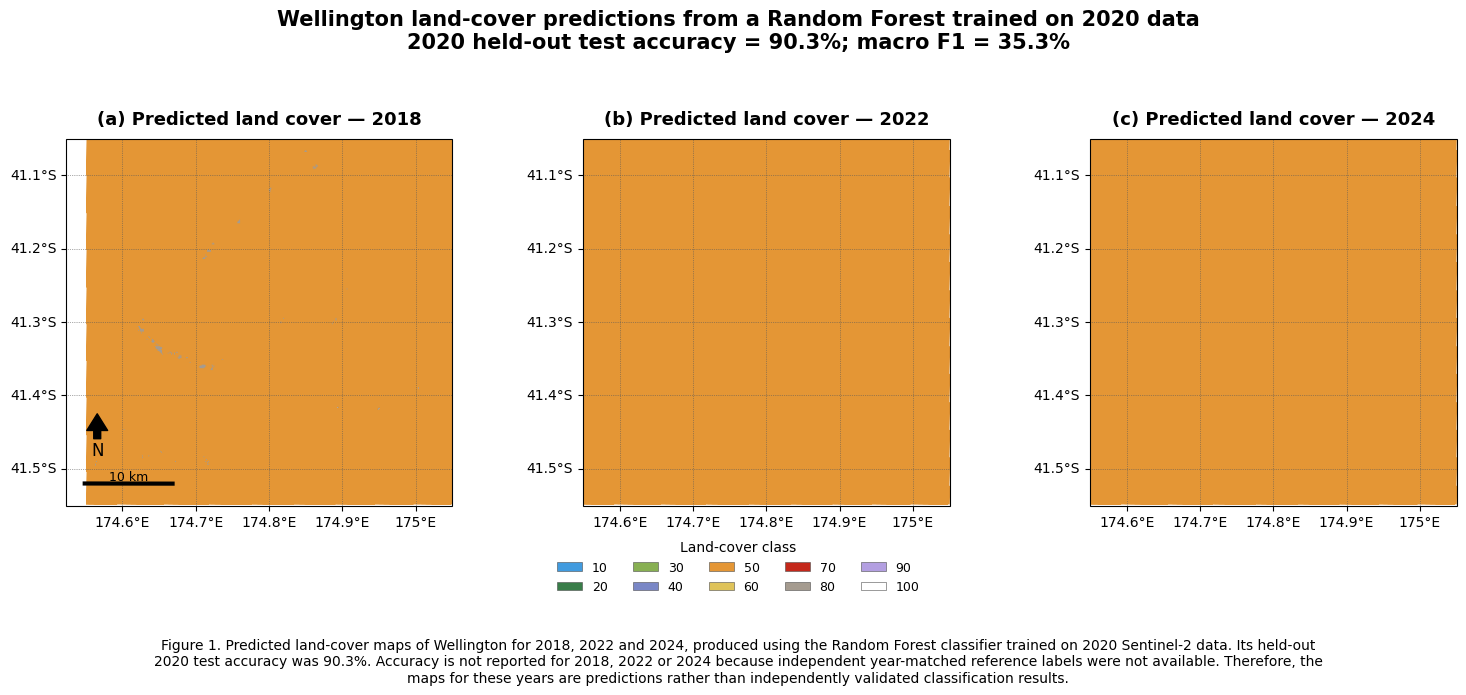


Figure saved as: wellington_landcover_2018_2022_2024.png


In [71]:
# ============================================================
# Imports
# ============================================================

import ee
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from matplotlib.patches import Patch
from geemap import cartoee

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


# ============================================================
# 1. Original validation code
# ============================================================

# Validate
validated = valid.classify(classifier, 'predicted')


# Function to export data for confusion matrix
def fc_to_lists(fc, classProp, predProp):
    values = fc.aggregate_array(classProp).getInfo()
    preds = fc.aggregate_array(predProp).getInfo()
    return values, preds


# Get predicted vs actual from validation set
y_true, y_pred = fc_to_lists(
    validated,
    'Map_remapped',
    'predicted'
)


# Labels for original classes
label_map = {
    i + 1: valid_classes.get(i).getInfo()
    for i in range(10)
}

label_names = [
    label_map[i + 1]
    for i in range(10)
]


# Confusion matrix
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(1, 11))
)

report = classification_report(
    y_true,
    y_pred,
    labels=list(range(1, 11)),
    target_names=[
        str(label)
        for label in label_names
    ]
)


# Pretty-print
print('Confusion Matrix:')

print(
    pd.DataFrame(
        cm,
        index=[
            f'Actual {label}'
            for label in label_names
        ],
        columns=[
            f'Pred {label}'
            for label in label_names
        ]
    )
)

print('\nClassification Report:')
print(report)


# ============================================================
# 2. Calculate statistics required by the figure
# ============================================================

test_accuracy_2020 = accuracy_score(
    y_true,
    y_pred
)

report_dict = classification_report(
    y_true,
    y_pred,
    labels=list(range(1, 11)),
    target_names=[
        str(label)
        for label in label_names
    ],
    output_dict=True,
    zero_division=0
)

print(
    f'\n2020 test accuracy: '
    f'{test_accuracy_2020:.2%}'
)

print(
    f'2020 macro-average F1: '
    f'{report_dict["macro avg"]["f1-score"]:.2%}'
)


# ============================================================
# 3. Recover the predictor bands used by the RF classifier
# ============================================================

classifier_information = (
    classifier
    .explain()
    .getInfo()
)

predictor_bands = list(
    classifier_information['importance'].keys()
)

print('\nPredictor bands used by the classifier:')
print(predictor_bands)


# Check whether the code can recreate all predictor bands.
supported_indices = [
    'NDVI',
    'NDBI'
]

sentinel_bands = [
    'B1',
    'B2',
    'B3',
    'B4',
    'B5',
    'B6',
    'B7',
    'B8',
    'B8A',
    'B9',
    'B11',
    'B12',
    'AOT',
    'WVP',
    'SCL',
    'QA60'
]

unsupported_predictors = [
    band
    for band in predictor_bands
    if band not in sentinel_bands + supported_indices
]

if unsupported_predictors:
    raise ValueError(
        'The classifier uses predictor bands that this code '
        'cannot recreate automatically: '
        f'{unsupported_predictors}. Use the same index-building '
        'function that was used for the 2020 training image.'
    )


# ============================================================
# 4. Define the Wellington study area
# ============================================================

# Earth Engine Rectangle uses:
# [west, south, east, north]
#
# Replace this rectangle with the exact geometry used to create
# the 2020 training image if that geometry is available.
wellington = ee.Geometry.Rectangle([
    174.55,
    -41.55,
    175.05,
    -41.05
])


# ============================================================
# 5. Determine the minimum required Sentinel-2 source bands
# ============================================================

required_source_bands = [
    band
    for band in predictor_bands
    if band in sentinel_bands
]

# NDVI requires B8 and B4.
if 'NDVI' in predictor_bands:
    required_source_bands.extend([
        'B8',
        'B4'
    ])

# NDBI requires B11 and B8.
if 'NDBI' in predictor_bands:
    required_source_bands.extend([
        'B11',
        'B8'
    ])

# SCL is required for cloud masking.
required_source_bands.append('SCL')

# Remove duplicate band names while preserving order.
required_source_bands = list(
    dict.fromkeys(required_source_bands)
)

print('\nSentinel-2 source bands required:')
print(required_source_bands)


# ============================================================
# 6. Define Sentinel-2 preprocessing
# ============================================================

def mask_s2_clouds(image):
    """Mask invalid, cloud, cirrus, shadow and snow pixels."""

    scl = image.select('SCL')

    clear_mask = (
        scl.neq(0)          # No data
        .And(scl.neq(1))    # Saturated or defective
        .And(scl.neq(3))    # Cloud shadow
        .And(scl.neq(8))    # Medium-probability cloud
        .And(scl.neq(9))    # High-probability cloud
        .And(scl.neq(10))   # Cirrus
        .And(scl.neq(11))   # Snow or ice
    )

    return image.updateMask(
        clear_mask
    )


def add_indices(image):
    """Add spectral indices required by the classifier."""

    if 'NDVI' in predictor_bands:
        ndvi = image.normalizedDifference(
            ['B8', 'B4']
        ).rename('NDVI')

        image = image.addBands(
            ndvi
        )

    if 'NDBI' in predictor_bands:
        ndbi = image.normalizedDifference(
            ['B11', 'B8']
        ).rename('NDBI')

        image = image.addBands(
            ndbi
        )

    return image


def prepare_s2_image(image):
    """Prepare an S2 image and retain only RF predictor bands."""

    # Select source bands before processing to reduce memory use.
    image = image.select(
        required_source_bands
    )

    image = mask_s2_clouds(
        image
    )

    image = add_indices(
        image
    )

    # Retain only the exact predictor bands expected by the RF.
    return image.select(
        predictor_bands
    )


# ============================================================
# 7. Create annual composites from monthly composites
# ============================================================

def make_year_composite(year):
    """Create a complete annual composite with lower memory use."""

    year_start = ee.Date.fromYMD(
        year,
        1,
        1
    )

    year_end = ee.Date.fromYMD(
        year + 1,
        1,
        1
    )

    collection = (
        ee.ImageCollection(
            'COPERNICUS/S2_SR_HARMONIZED'
        )
        .filterBounds(
            wellington
        )
        .filterDate(
            year_start,
            year_end
        )
        .filter(
            ee.Filter.lt(
                'CLOUDY_PIXEL_PERCENTAGE',
                80
            )
        )
        .map(
            prepare_s2_image
        )
    )

    monthly_images = []

    for month in range(1, 13):
        month_start = ee.Date.fromYMD(
            year,
            month,
            1
        )

        month_end = month_start.advance(
            1,
            'month'
        )

        monthly_composite = (
            collection
            .filterDate(
                month_start,
                month_end
            )
            .median()
            .set(
                'system:time_start',
                month_start.millis()
            )
        )

        monthly_images.append(
            monthly_composite
        )

    # Combine the twelve monthly composites.
    annual_composite = (
        ee.ImageCollection.fromImages(
            monthly_images
        )
        .median()
        .clip(
            wellington
        )
        .reproject(
            crs='EPSG:2193',
            scale=100
        )
    )

    return annual_composite


# ============================================================
# 8. Create annual land-cover maps
# ============================================================

years = [
    2018,
    2022,
    2024
]

annual_composites = {
    year: make_year_composite(year)
    for year in years
}

landcover_maps = {
    year: (
        annual_composites[year]
        .classify(
            classifier
        )
        .rename(
            'landcover'
        )
        .toInt()
    )
    for year in years
}

print(
    '\nThe 2018, 2022 and 2024 land-cover '
    'images were created successfully.'
)


# ============================================================
# 9. Define colours and map extent
# ============================================================

palette = [
    '419BDF',
    '397D49',
    '88B053',
    '7A87C6',
    'E49635',
    'DFC35A',
    'C4281B',
    'A59B8F',
    'B39FE1',
    'FFFFFF'
]

vis_params = {
    'min': 1,
    'max': 10,
    'palette': palette
}

# Derive the cartoee extent from the Earth Engine study area.
bounds_coordinates = (
    wellington
    .bounds()
    .coordinates()
    .getInfo()[0]
)

longitude_values = [
    coordinate[0]
    for coordinate in bounds_coordinates
]

latitude_values = [
    coordinate[1]
    for coordinate in bounds_coordinates
]

west = min(longitude_values)
east = max(longitude_values)
south = min(latitude_values)
north = max(latitude_values)

# cartoee uses [east, south, west, north].
plot_region = [
    east,
    south,
    west,
    north
]

panel_labels = [
    '(a)',
    '(b)',
    '(c)'
]


# ============================================================
# 10. Create the publication-quality figure
# ============================================================

# Close figures left behind by previous failed attempts.
plt.close('all')

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 7),
    subplot_kw={
        'projection': ccrs.PlateCarree()
    }
)


for ax, year, panel_label in zip(
    axes,
    years,
    panel_labels
):
    try:
        # Render the 100 m classification at a moderate size.
        cartoee.add_layer(
            ax,
            landcover_maps[year],
            region=plot_region,
            vis_params=vis_params,
            dims=400
        )

    except Exception:
        # Retry at a lower resolution if Earth Engine
        # reports a server-side memory error.
        print(
            f'{year} exceeded the memory limit. '
            'Retrying at 200 m.'
        )

        fallback_map = (
            landcover_maps[year]
            .reproject(
                crs='EPSG:2193',
                scale=200
            )
        )

        cartoee.add_layer(
            ax,
            fallback_map,
            region=plot_region,
            vis_params=vis_params,
            dims=300
        )

    # Add coordinate gridlines.
    cartoee.add_gridlines(
        ax,
        interval=0.1,
        linestyle=':',
        linewidth=0.5,
        color='0.35',
        xtick_rotation=0
    )

    # Add the panel title.
    ax.set_title(
        f'{panel_label} Predicted land cover — {year}',
        fontsize=13,
        fontweight='bold',
        pad=10
    )


# ============================================================
# 11. Add map elements
# ============================================================

cartoee.add_scale_bar_lite(
    axes[0],
    length=10,
    unit='km',
    xy=(0.12, 0.06),
    linewidth=3,
    fontsize=9,
    color='black'
)

cartoee.add_north_arrow(
    axes[0],
    text='N',
    xy=(0.08, 0.25),
    arrow_length=0.10,
    fontsize=12,
    text_color='black',
    arrow_color='black'
)


# Create one legend item for each land-cover class.
legend_handles = [
    Patch(
        facecolor=f'#{colour}',
        edgecolor='0.3',
        linewidth=0.4,
        label=str(class_name)
    )
    for colour, class_name in zip(
        palette,
        label_names
    )
]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.13),
    ncol=5,
    frameon=False,
    title='Land-cover class',
    fontsize=9,
    title_fontsize=10
)


# ============================================================
# 12. Add the title and caption
# ============================================================

fig.suptitle(
    'Wellington land-cover predictions from a Random Forest '
    'trained on 2020 data\n'
    f'2020 held-out test accuracy = {test_accuracy_2020:.1%}; '
    f'macro F1 = '
    f'{report_dict["macro avg"]["f1-score"]:.1%}',
    fontsize=15,
    fontweight='bold',
    y=0.98
)

caption = (
    'Figure 1. Predicted land-cover maps of Wellington for 2018, '
    '2022 and 2024, produced using the Random Forest classifier '
    'trained on 2020 Sentinel-2 data. Its held-out 2020 test '
    f'accuracy was {test_accuracy_2020:.1%}. Accuracy is not '
    'reported for 2018, 2022 or 2024 because independent '
    'year-matched reference labels were not available. Therefore, '
    'the maps for these years are predictions rather than '
    'independently validated classification results.'
)

fig.text(
    0.5,
    0.015,
    textwrap.fill(
        caption,
        width=165
    ),
    ha='center',
    va='bottom',
    fontsize=10
)

plt.tight_layout(
    rect=[
        0.02,
        0.25,
        0.98,
        0.90
    ]
)


# ============================================================
# 13. Save and display the figure
# ============================================================

output_filename = (
    'wellington_landcover_2018_2022_2024.png'
)

plt.savefig(
    output_filename,
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print(
    f'\nFigure saved as: {output_filename}'
)

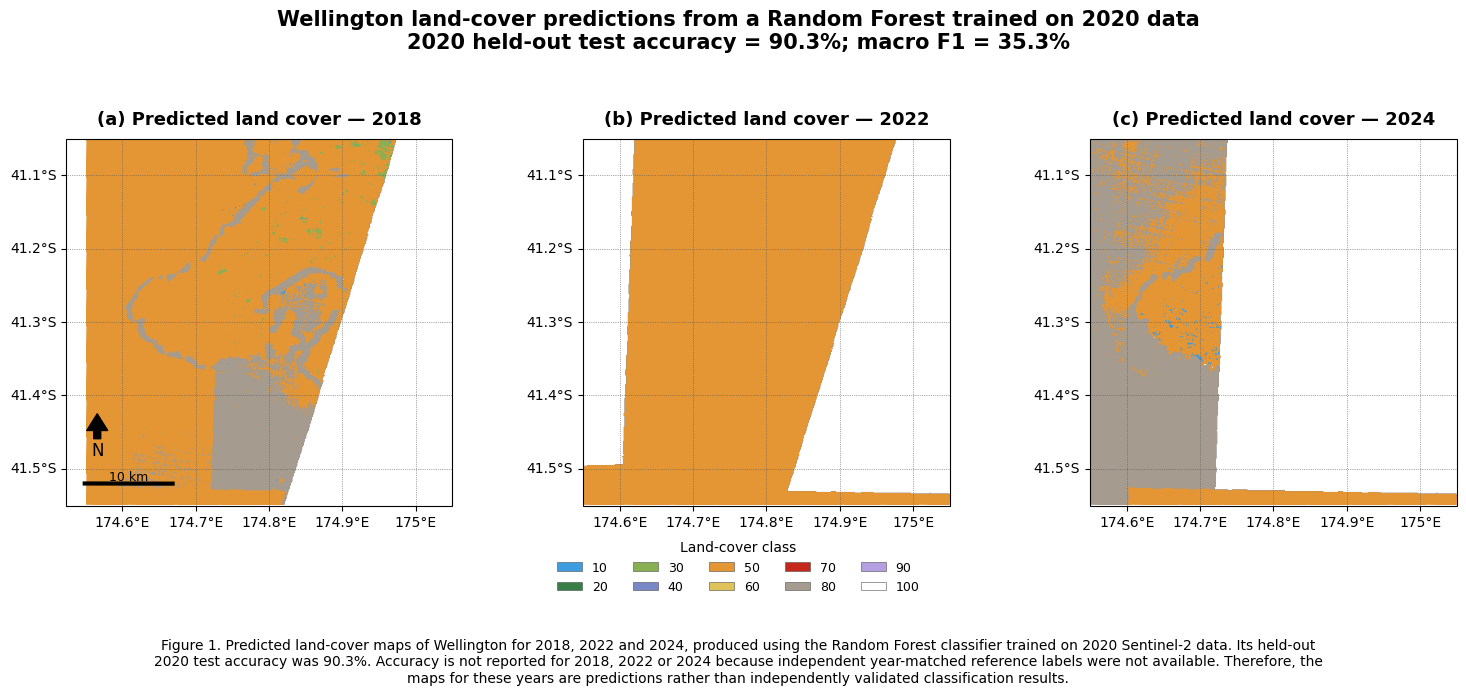

In [68]:
import textwrap
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from matplotlib.patches import Patch
from geemap import cartoee


# Close incomplete figures produced by previous failed attempts.
plt.close('all')


# ============================================================
# 1. Define the class colours
# ============================================================

palette = [
    '419BDF',
    '397D49',
    '88B053',
    '7A87C6',
    'E49635',
    'DFC35A',
    'C4281B',
    'A59B8F',
    'B39FE1',
    'FFFFFF'
]

vis_params = {
    'min': 1,
    'max': 10,
    'palette': palette
}


# ============================================================
# 2. Define the map extent
# ============================================================

# cartoee uses [east, south, west, north].
plot_region = [
    175.05,
    -41.55,
    174.55,
    -41.05
]

panel_labels = [
    '(a)',
    '(b)',
    '(c)'
]


# ============================================================
# 3. Create the three map panels
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 7),
    subplot_kw={
        'projection': ccrs.PlateCarree()
    }
)


for ax, year, panel_label in zip(
    axes,
    years,
    panel_labels
):
    try:
        # First attempt: render the 100 m map at 450 pixels.
        cartoee.add_layer(
            ax,
            landcover_maps[year],
            region=plot_region,
            vis_params=vis_params,
            dims=450
        )

    except Exception as error:
        # If Earth Engine still exceeds its memory limit,
        # retry using a 200 m display image.
        print(
            f'{year} exceeded the memory limit. '
            'Retrying at 200 m.'
        )

        fallback_map = (
            landcover_maps[year]
            .reproject(
                crs='EPSG:2193',
                scale=200
            )
        )

        cartoee.add_layer(
            ax,
            fallback_map,
            region=plot_region,
            vis_params=vis_params,
            dims=300
        )

    # Add coordinate gridlines.
    cartoee.add_gridlines(
        ax,
        interval=0.1,
        linestyle=':',
        linewidth=0.5,
        color='0.35',
        xtick_rotation=0
    )

    # Add the panel title.
    ax.set_title(
        f'{panel_label} Predicted land cover — {year}',
        fontsize=13,
        fontweight='bold',
        pad=10
    )


# ============================================================
# 4. Add the scale bar and north arrow
# ============================================================

cartoee.add_scale_bar_lite(
    axes[0],
    length=10,
    unit='km',
    xy=(0.12, 0.06),
    linewidth=3,
    fontsize=9,
    color='black'
)

cartoee.add_north_arrow(
    axes[0],
    text='N',
    xy=(0.08, 0.25),
    arrow_length=0.10,
    fontsize=12,
    text_color='black',
    arrow_color='black'
)


# ============================================================
# 5. Add the land-cover legend
# ============================================================

legend_handles = [
    Patch(
        facecolor=f'#{colour}',
        edgecolor='0.3',
        linewidth=0.4,
        label=class_name
    )
    for colour, class_name in zip(
        palette,
        label_names
    )
]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.13),
    ncol=5,
    frameon=False,
    title='Land-cover class',
    fontsize=9,
    title_fontsize=10
)


# ============================================================
# 6. Add the title and required caption
# ============================================================

fig.suptitle(
    'Wellington land-cover predictions from a Random Forest '
    'trained on 2020 data\n'
    f'2020 held-out test accuracy = {test_accuracy_2020:.1%}; '
    f'macro F1 = '
    f'{report_dict["macro avg"]["f1-score"]:.1%}',
    fontsize=15,
    fontweight='bold',
    y=0.98
)

caption = (
    'Figure 1. Predicted land-cover maps of Wellington for 2018, '
    '2022 and 2024, produced using the Random Forest classifier '
    'trained on 2020 Sentinel-2 data. Its held-out 2020 test '
    f'accuracy was {test_accuracy_2020:.1%}. Accuracy is not '
    'reported for 2018, 2022 or 2024 because independent '
    'year-matched reference labels were not available. Therefore, '
    'the maps for these years are predictions rather than '
    'independently validated classification results.'
)

fig.text(
    0.5,
    0.015,
    textwrap.fill(
        caption,
        width=165
    ),
    ha='center',
    va='bottom',
    fontsize=10
)

plt.tight_layout(
    rect=[
        0.02,
        0.25,
        0.98,
        0.90
    ]
)


# ============================================================
# 7. Save and display the figure
# ============================================================

plt.savefig(
    'wellington_landcover_2018_2022_2024.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

In [75]:
import pandas as pd
import ee


# ============================================================
# 1. Diagnose class imbalance in the validation data
# ============================================================

true_distribution = (
    pd.Series(y_true)
    .value_counts()
    .sort_index()
    .rename('Actual count')
)

predicted_distribution = (
    pd.Series(y_pred)
    .value_counts()
    .sort_index()
    .rename('Predicted count')
)

distribution_table = pd.concat(
    [
        true_distribution,
        predicted_distribution
    ],
    axis=1
).fillna(0).astype(int)

distribution_table['Actual percentage'] = (
    distribution_table['Actual count']
    / distribution_table['Actual count'].sum()
    * 100
)

distribution_table['Predicted percentage'] = (
    distribution_table['Predicted count']
    / distribution_table['Predicted count'].sum()
    * 100
)

print('=' * 70)
print('1. Validation class distribution')
print('=' * 70)

display(
    distribution_table.round(2)
)


# ============================================================
# 2. Compare validation values with the reconstructed 2020 image
# ============================================================

# Recreate a 2020 image using the current preprocessing function.
diagnostic_2020 = make_year_composite(2020)

print('\n' + '=' * 70)
print('2. Validation-sample predictor statistics')
print('=' * 70)

for band in predictor_bands:
    sample_statistics = (
        valid
        .aggregate_stats(band)
        .getInfo()
    )

    print(f'\nBand: {band}')
    print(sample_statistics)


# Calculate the 5th, 50th and 95th percentiles of each image band.
image_statistics = (
    diagnostic_2020
    .select(predictor_bands)
    .reduceRegion(
        reducer=ee.Reducer.percentile([
            5,
            50,
            95
        ]),
        geometry=wellington,
        scale=500,
        maxPixels=1e7,
        bestEffort=True
    )
    .getInfo()
)

print('\n' + '=' * 70)
print('3. Reconstructed 2020 image predictor statistics')
print('=' * 70)

for key, value in image_statistics.items():
    print(f'{key}: {value}')


# ============================================================
# 3. Inspect the reconstructed 2020 classification
# ============================================================

diagnostic_2020_classified = (
    diagnostic_2020
    .classify(classifier)
    .rename('landcover')
)

prediction_histogram_2020 = (
    diagnostic_2020_classified
    .reduceRegion(
        reducer=ee.Reducer.frequencyHistogram(),
        geometry=wellington,
        scale=500,
        maxPixels=1e7,
        bestEffort=True
    )
    .getInfo()
)

print('\n' + '=' * 70)
print('4. Reconstructed 2020 map class distribution')
print('=' * 70)

print(prediction_histogram_2020)


# ============================================================
# 4. Print basic diagnostic guidance
# ============================================================

dominant_actual_class = (
    distribution_table['Actual percentage']
    .idxmax()
)

dominant_actual_percentage = (
    distribution_table
    .loc[
        dominant_actual_class,
        'Actual percentage'
    ]
)

dominant_predicted_class = (
    distribution_table['Predicted percentage']
    .idxmax()
)

dominant_predicted_percentage = (
    distribution_table
    .loc[
        dominant_predicted_class,
        'Predicted percentage'
    ]
)

print('\n' + '=' * 70)
print('5. Diagnostic summary')
print('=' * 70)

print(
    f'Dominant actual validation class: '
    f'{dominant_actual_class} '
    f'({dominant_actual_percentage:.2f}%)'
)

print(
    f'Dominant predicted validation class: '
    f'{dominant_predicted_class} '
    f'({dominant_predicted_percentage:.2f}%)'
)

if dominant_actual_percentage >= 80:
    print(
        '\nWarning: The validation data are strongly imbalanced. '
        'Overall accuracy may therefore be misleading.'
    )

if dominant_predicted_percentage >= 80:
    print(
        '\nWarning: The classifier predicts one class for most '
        'validation samples.'
    )

print(
    '\nCompare the validation-sample band values with the '
    'reconstructed 2020 image percentiles.'
)

print(
    'If one dataset uses values around 0–1 and the other uses '
    'values around 0–10000, the reflectance scaling is inconsistent.'
)

print(
    'If the reconstructed 2020 map is also dominated by one class, '
    'the current annual-composite function does not reproduce the '
    'original 2020 model inputs.'
)

1. Validation class distribution


,Actual count,Predicted count,Actual percentage,Predicted percentage
1,264,275,24.81,25.85
2,1,1,0.09,0.09
3,197,192,18.52,18.05
5,35,37,3.29,3.48
6,5,3,0.47,0.28
8,559,556,52.54,52.26
9,3,0,0.28,0.00



2. Validation-sample predictor statistics



Band: B2
{'max': 0.36000001430511475, 'mean': 0.035416397355863195, 'min': 0.0005000000237487257, 'sample_sd': 0.022756157019818122, 'sample_var': 0.0005178426823106176, 'sum': 37.68304678663844, 'sum_sq': 1.8850645298713575, 'total_count': 1064, 'total_sd': 0.022745460823213184, 'total_var': 0.0005173559880603258, 'valid_count': 1064, 'weight_sum': 1064, 'weighted_sum': 37.68304678663844}

Band: B3
{'max': 0.36559998989105225, 'mean': 0.04127014140052287, 'min': 0.004100000020116568, 'sample_sd': 0.02785839194222448, 'sample_var': 0.0007760900016065978, 'sum': 43.91143045015633, 'sum_sq': 2.6372146154849907, 'total_count': 1064, 'total_sd': 0.027845297515206244, 'total_var': 0.000775360593710351, 'valid_count': 1064, 'weight_sum': 1064, 'weighted_sum': 43.91143045015633}

Band: B4
{'max': 0.3783999979496002, 'mean': 0.02698146983503217, 'min': 0.0017000000225380063, 'sample_sd': 0.033376918569191893, 'sample_var': 0.0011140186931744664, 'sum': 28.70828390447423, 'sum_sq': 1.958793567

# SVMs Applied to Satellite Data

In [69]:
# Define and train the SVM classifier
class_property = 'Map_remapped'
svm = ee.Classifier.libsvm(kernelType='RBF', gamma=0.5, cost=10).train(
    features=train,
    classProperty=class_property,
    inputProperties=bands
)

# Classify validation and test sets
val_classified = valid.classify(svm)
test_classified = test.classify(svm)

# Evaluate test performance
test_matrix = test_classified.errorMatrix(class_property, 'classification')
print("Confusion Matrix:")
print(pd.DataFrame(cm, index=[f"Actual {l}" for l in label_names],
                       columns=[f"Pred {l}" for l in label_names]))
print("\nClassification Report:")
print(report)

Confusion Matrix:
            Pred 10  Pred 20  Pred 30  Pred 40  Pred 50  Pred 60  Pred 70  \
Actual 10       230        1       31        0        2        0        0   
Actual 20         1        0        0        0        0        0        0   
Actual 30        39        0      154        0        4        0        0   
Actual 40         0        0        0        0        0        0        0   
Actual 50         5        0        3        0       23        2        0   
Actual 60         0        0        1        0        2        1        0   
Actual 70         0        0        0        0        0        0        0   
Actual 80         0        0        0        0        6        0        0   
Actual 90         0        0        3        0        0        0        0   
Actual 100        0        0        0        0        0        0        0   

            Pred 80  Pred 90  Pred 100  
Actual 10         0        0         0  
Actual 20         0        0         0  
Actual 30  

# (6) Exercise: train an SVM model using the Landcare NZ 2018 landcover database record for the region. Producing a landcover map of Great Barrier (Aotea) Island for 2018 (based off the Austral summer of 18/19 S2).

Your map should be presented at a publication quality level with all the usual map components (scale, legend, north arrow, data attribution).

You will need to provide performance statistics of the model within your figure.

*   Here you can access the landcover database: https://lris.scinfo.org.nz/layer/104400-lcdb-v50-land-cover-database-version-50-mainland-new-zealand/. You will need to explore for yourself how to extract this data and then upload it to colab, then how to plug it into the SVM algorithim. I have provided some starter code below.

An intial workflow to get the data into the state you need it in to then use it as training data might look like:
- Download the ZIP manually from their browser, having set your area of interest and used the 'Export' tool top right.
- Upload it to Colab.
- Unzip it and load with GeoPandas.
(25 pts)



In [77]:
# Code to get you started
import zipfile
import geopandas as gpd

# Upload the ZIP manually using the Colab UI
from google.colab import files
uploaded = files.upload()  # <- Expects a ZIP

# Unzip
with zipfile.ZipFile("LCDB_v5.zip", 'r') as zip_ref: #<- Check file names
    zip_ref.extractall("lcdb")

# Read shapefile
gdf = gpd.read_file("lcdb/LCDB_v5.shp") #<- Check file names
print(gdf.head())


KeyboardInterrupt: 

In [78]:
from pathlib import Path
import geopandas as gpd

# 搜索已经解压出来的所有 shp 文件
shp_files = list(Path("/content/lcdb").rglob("*.shp"))

print("找到的 shp 文件：")
for shp in shp_files:
    print(shp)

if len(shp_files) == 0:
    raise FileNotFoundError("lcdb 文件夹中没有找到 shp 文件")

# 读取找到的第一个 shp
gdf = gpd.read_file(shp_files[0])

print("成功读取！")
print("记录数量：", len(gdf))
print("坐标系：", gdf.crs)
print("字段：", gdf.columns.tolist())

gdf.head()

找到的 shp 文件：
/content/lcdb/lcdb-v50-land-cover-database-version-50-mainland-new-zealand.shp
成功读取！
记录数量： 532
坐标系： EPSG:2193
字段： ['Name_2018', 'Name_2012', 'Name_2008', 'Name_2001', 'Name_1996', 'Class_2018', 'Class_2012', 'Class_2008', 'Class_2001', 'Class_1996', 'Wetland_18', 'Wetland_12', 'Wetland_08', 'Wetland_01', 'Wetland_96', 'Onshore_18', 'Onshore_12', 'Onshore_08', 'Onshore_01', 'Onshore_96', 'EditAuthor', 'EditDate', 'LCDB_UID', 'geometry']


,Name_2018,Name_2012,Name_2008,Name_2001,Name_1996,Class_2018,Class_2012,Class_2008,Class_2001,Class_1996,...,Wetland_96,Onshore_18,Onshore_12,Onshore_08,Onshore_01,Onshore_96,EditAuthor,EditDate,LCDB_UID,geometry
0,Indigenous Forest,Indigenous Forest,Indigenous Forest,Indigenous Forest,Indigenous Forest,69,69,69,69,69,...,no,yes,yes,yes,yes,yes,Terralink,2004-06-30,lcdb1000168553,"POLYGON ((1820024.88 6001115.814, 1820021.712 ..."
1,Sand or Gravel,Sand or Gravel,Sand or Gravel,Sand or Gravel,Sand or Gravel,10,10,10,10,10,...,no,yes,yes,yes,yes,yes,Terralink,2004-06-30,lcdb1000009545,"POLYGON ((1820054.749 6001263.521, 1820067.563..."
2,Indigenous Forest,Indigenous Forest,Indigenous Forest,Indigenous Forest,Indigenous Forest,69,69,69,69,69,...,no,yes,yes,yes,yes,yes,Terralink,2004-06-30,lcdb1000168544,"POLYGON ((1818892.667 6000858.715, 1818932.048..."
3,Sand or Gravel,Sand or Gravel,Sand or Gravel,Sand or Gravel,Sand or Gravel,10,10,10,10,10,...,no,yes,yes,yes,yes,yes,Terralink,2004-06-30,lcdb1000009547,"POLYGON ((1818879.751 6001641.58, 1818900.374 ..."
4,Indigenous Forest,Indigenous Forest,Indigenous Forest,Indigenous Forest,Indigenous Forest,69,69,69,69,69,...,no,yes,yes,yes,yes,yes,Terralink,2004-06-30,lcdb1000168423,"POLYGON ((1819193.973 5997373.55, 1819165.748 ..."
